In [1]:
# %pip install matplotlib

  Using cached matplotlib-3.9.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.2.1-cp311-cp311-win_amd64.whl.metadata (5.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.51.0-cp311-cp311-win_amd64.whl.metadata (162 kB)
  Using cached kiwisolver-1.4.5-cp311-cp311-win_amd64.whl.metadata (6.5 kB)
  Using cached pillow-10.3.0-cp311-cp311-win_amd64.whl.metadata (9.4 kB)
Using cached matplotlib-3.9.0-cp311-cp311-win_amd64.whl (8.0 MB)
Using cached contourpy-1.2.1-cp311-cp311-win_amd64.whl (188 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.51.0-cp311-cp311-win_amd64.whl (2.2 MB)
Using cached kiwisolver-1.4.5-cp311-cp311-win_amd64.whl (56 kB)
Using cached pillow-10.3.0-cp311-cp311-win_amd64.whl (2.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

Matplotlib is building the font cache; this may take a moment.


In [3]:
def calculate_return(signal):
    # signal = [日期, 評分, 價格]
    hold = 0  # 持有的股數
    balance = 10000000
    init_balance = balance

    list_rtn = []

    for item in signal:
        score = float(item[1])
        price = float(item[2])

        # if hold == 0:
        #     if score > 0:
        #         hold += int(balance/price)
        #         balance = 0
        # elif hold > 0:
        #     if score < 0:
        #         balance += price*hold
        #         hold = 0

        if hold == 0:
            if score == 2:
                hold += int(balance/price)
                balance = 0
            elif score == 1:
                hold += int((balance/2)/price)
                balance = int(balance/2)
        elif hold > 0:
            if score < 0:
                balance += price*hold
                hold = 0
            elif score == 2:
                hold += int(balance/price)
                balance = 0
        # print(f"score: {score}, price: {price}, hold: {hold}, balance: {balance}, total: {balance + hold*price}")

        list_rtn.append((balance + hold*price)/init_balance)
    
    balance += hold*price
    last_price = float(signal[len(signal) - 1][2])
    r = balance/init_balance

    # plt.title({stock_id})
    # plt.plot(list_rtn, label=f'strategy', color='red')
    # plt.plot(list_bnh, label='buy and hold', color='blue')
    # plt.legend()
    # plt.show()

    return round(r, 5)

157 X1.0352590000000002
158 X1.036081
159 X1.1285500000000002
160 X1.1575650000000002
161 X1.0231
162 X1.0644380000000002
163 X1.0717830000000002
164 X1.018677
165 X1.11962
166 X1.127034
167 X1.00229
168 X1.061099
169 X1.0538199999999998
170 X1.038993
171 X1.095087
172 X1.0667360000000001
173 X1.1568589999999996
174 X1.0785129999999998
175 X1.066678
176 X1.097266
177 X1.069112
178 X1.049497
179 X1.0539079999999998
180 X1.005041
181 X1.05751
182 X1.04197
183 X1.0986359999999997
184 X1.0706840000000002
185 X0.9658180000000002
186 X1.1356259999999998
187 X1.1138600000000003
188 X1.061679
189 X1.176817
190 X1.083356
191 X1.135925
192 X1.067589
193 X1.047024
194 X1.121252
195 X1.061585
196 X1.0447799999999998
197 X1.0993229999999998
198 X1.093194
199 X1.027777
200 X1.014095
201 X1.121814
202 X1.173562
203 X1.1759560000000002
204 X1.061593
205 X1.08757
206 X1.011652
207 X1.0866649999999998
208 X1.12602
209 X0.994915
210策略勝利
211 X1.115099
212 X1.0705959999999999
213 X1.094558
214 X1.050466
21

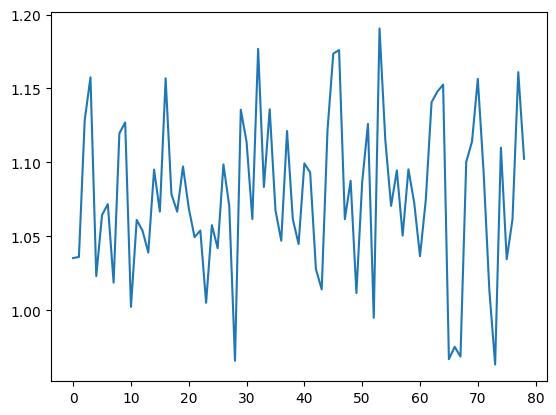

In [9]:
# 88 ~ 137 -100~100
# 157 ~ 235 #非常好(2) #好(1) #無關(0) #不好(-1) #非常不好(-2)

# 20220101 ~ 20231231 兩年的10擋股票報酬率 1.186132
# 20230101 ~ 20231231 一年的10擋股票報酬率 1.170022
import matplotlib.pyplot as plt
import ast
list_2 = []

for i in range(157, 236):
    rtns = []
    bnhs = []
    eval_list = []

    with open("eval_gemini/output"+str(i), "r", encoding='utf-8') as f:
        data = f.read()
        eval_list = ast.literal_eval(data.split("原始數據")[1])

    for list in eval_list:
        rtn = calculate_return(list)
        # print(f'報酬率:{rtn}，總額投入報酬率:{bnh} ',end="==>")  
        # print("勝利" if rtn > bnh else "失敗")
        rtns.append(rtn)

    # print("_"*50)
    # print(f'平均報酬率:{sum(rtns) / len(rtns)}，平均總額投入報酬率:{1.186132}')
    print(str(i) + "策略勝利" if sum(rtns) / len(rtns) > 1.186132 else str(i) + " X" + str(sum(rtns) / len(rtns)))
    list_2.append(sum(rtns) / len(rtns))

plt.plot(list_2)
print(list_2)

In [5]:
import ast
with open("eval_gemini/output234", "r", encoding='utf-8') as f:
    data = f.read()
    eval_list = ast.literal_eval(data.split("原始數據")[1])

for list in eval_list:

    rtn = calculate_return(list)
    # print(f'報酬率:{rtn}，總額投入報酬率:{bnh} ',end="==>")  
    # print("勝利" if rtn > bnh else "失敗")
    rtns.append(rtn)



# print("_"*50)
# print(f'平均報酬率:{sum(rtns) / len(rtns)}，平均總額投入報酬率:{1.186132}')
print(str(i) + "策略勝利" if sum(rtns) / len(rtns) > 1.186132 else str(i) + " X" + str(sum(rtns) / len(rtns)))

# raw_data.append(signal_2_np.tolist())

157 X1.161064
